# Job Market Skill Analyzer

This project analyzes data science job postings to identify important skills, job roles, and trends in the job market.

## 1. Import Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Dataset

In [4]:
df = pd.read_csv("Cleaned_DS_Jobs.csv")
df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Type of ownership,Industry,...,company_age,python,excel,hadoop,spark,aws,tableau,big_data,job_simp,seniority
0,Sr Data Scientist,137-171,Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst,"New York, NY","New York, NY",1001 to 5000 employees,Nonprofit Organization,Insurance Carriers,...,27,0,0,0,0,1,0,0,data scientist,senior
1,Data Scientist,137-171,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,Company - Public,Research & Development,...,52,0,0,1,0,0,0,1,data scientist,na
2,Data Scientist,137-171,Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group,"Boston, MA","Boston, MA",1001 to 5000 employees,Private Practice / Firm,Consulting,...,39,1,1,0,0,1,0,0,data scientist,na
3,Data Scientist,137-171,JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,Company - Public,Electrical & Electronic Manufacturing,...,20,1,1,0,0,1,0,0,data scientist,na
4,Data Scientist,137-171,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions,"New York, NY","New York, NY",51 to 200 employees,Company - Private,Advertising & Marketing,...,22,1,1,0,0,0,0,0,data scientist,na


## 3. Understand Dataset

In [5]:
print(df.columns.tolist())

['Job Title', 'Salary Estimate', 'Job Description', 'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'min_salary', 'max_salary', 'avg_salary', 'job_state', 'same_state', 'company_age', 'python', 'excel', 'hadoop', 'spark', 'aws', 'tableau', 'big_data', 'job_simp', 'seniority']


## 4. Data Cleaning

### Checking the number of rows and columns in the dataset

In [6]:
print(df.shape)

(660, 27)


### Removing duplicate records from the dataset to ensure clean data.

In [7]:
df = df.drop_duplicates()
print(df.shape)

(648, 27)


 ### Handling missing values in Industry, Sector, and Rating Columns.

In [8]:
df['Industry'] = df['Industry'].fillna('Unknown')
df['Sector'] = df['Sector'].fillna('Unknown')
df['Rating'] = df['Rating'].fillna(0)

### Replacing invalid '-1' values with 'Unknown' for better analysis.

In [9]:
df['Industry'] = df['Industry'].replace('-1', 'Unknown')
df['Sector'] = df['Sector'].replace('-1', 'Unknown')
df['Rating'] = df['Rating'].fillna(0)

### Finding the most common job titles in the dataset.

In [12]:
top_titles = df['Job Title'].value_counts().head(10)
print(top_titles)

Job Title
Data Scientist                                                                                      322
Data Engineer                                                                                        26
Senior Data Scientist                                                                                19
Machine Learning Engineer                                                                            14
Data Analyst                                                                                         12
Senior Data Analyst                                                                                   6
Senior Data Engineer                                                                                  4
ENGINEER - COMPUTER SCIENTIST - RESEARCH COMPUTER SCIENTIST - SIGNAL PROCESSING - SAN ANTONIO OR      4
Data Science Software Engineer                                                                        4
Data Scientist - TS/SCI FSP or CI Required            

## 5. Job Title Analysis

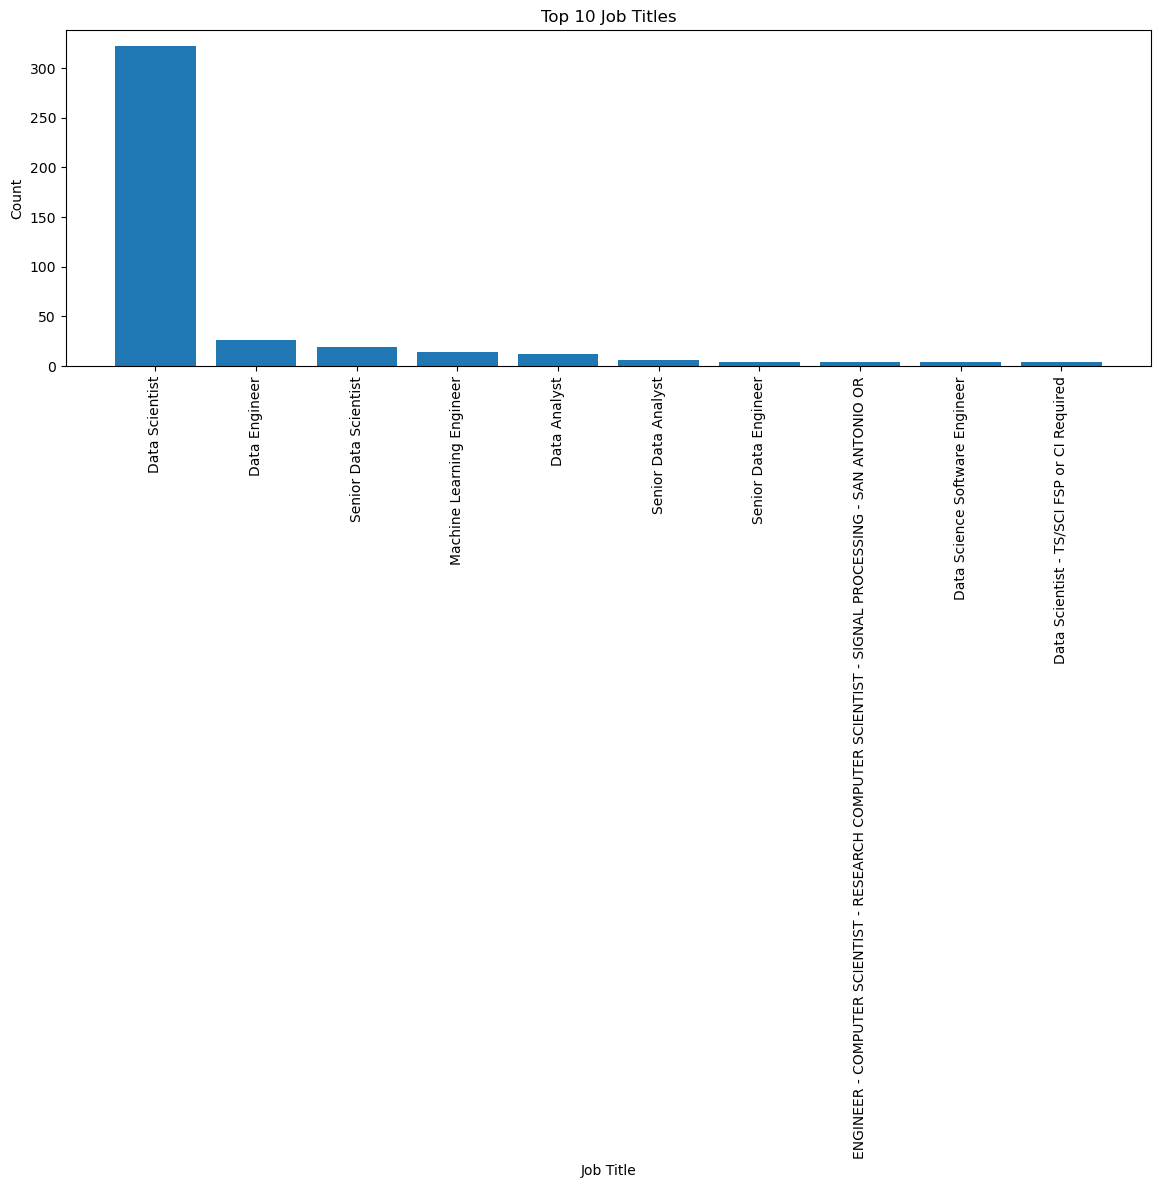

In [13]:
plt.figure(figsize=(14,7))
plt.bar(top_titles.index, top_titles.values)
plt.xticks(rotation=90)
plt.title("Top 10 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.subplots_adjust(bottom=0.4)
plt.show()

## 6. Industry Analysis

In [14]:
top_industries = df['Industry'].value_counts().head(10)
print(top_industries)

Industry
Biotech & Pharmaceuticals                  66
IT Services                                60
Unknown                                    60
Computer Hardware & Software               55
Aerospace & Defense                        46
Enterprise Software & Network Solutions    40
Consulting                                 38
Staffing & Outsourcing                     36
Insurance Carriers                         28
Advertising & Marketing                    23
Name: count, dtype: int64


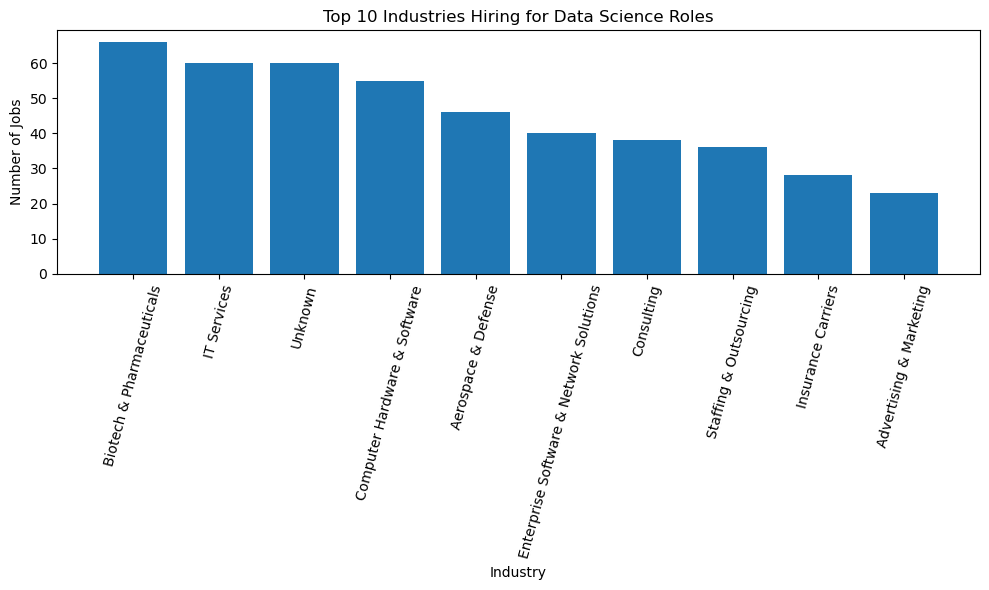

In [15]:
plt.figure(figsize=(10,6))
plt.bar(top_industries.index, top_industries.values)
plt.xticks(rotation=75)
plt.title("Top 10 Industries Hiring for Data Science Roles")
plt.xlabel("Industry")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()

## 7. Sector Analysis

In [16]:
top_sectors = df['Sector'].value_counts().head(10)
print(top_sectors)

Sector
Information Technology       178
Business Services            120
Biotech & Pharmaceuticals     66
Unknown                       60
Aerospace & Defense           46
Insurance                     32
Finance                       30
Manufacturing                 23
Health Care                   21
Government                    17
Name: count, dtype: int64


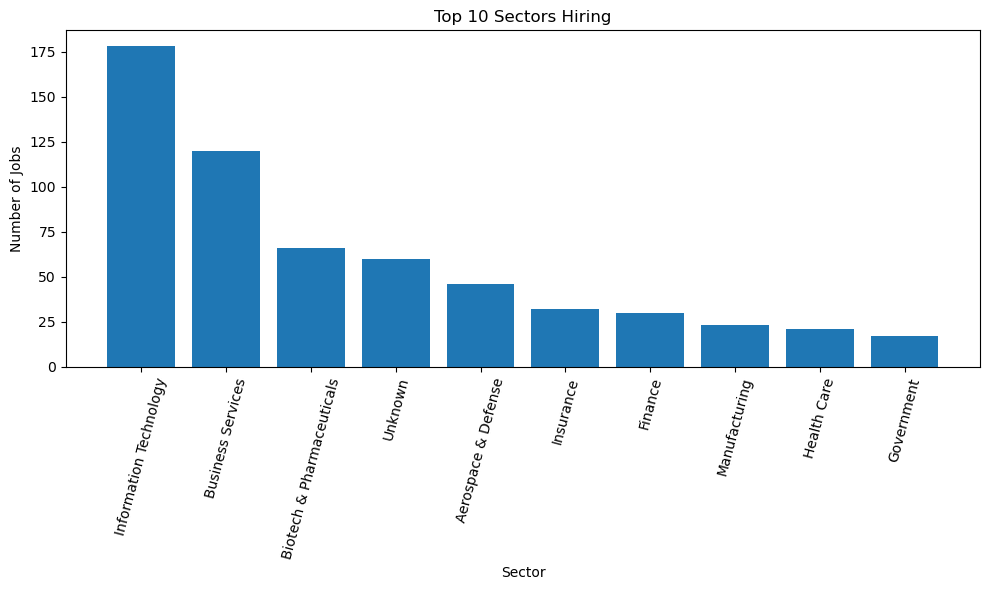

In [17]:
plt.figure(figsize=(10,6))
plt.bar(top_sectors.index, top_sectors.values)
plt.xticks(rotation=75)
plt.title("Top 10 Sectors Hiring")
plt.xlabel("Sector")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()

## 8. Top Hiring Companies
### Finding the companies that are posting the most job openings.

In [18]:
top_companies = df['Company Name'].value_counts().head(10)
print(top_companies)

Company Name
Maxar Technologies              12
Tempus Labs                     11
AstraZeneca                     10
Klaviyo                          8
Phoenix Operations Group         7
Autodesk                         7
Novetta                          6
Southwest Research Institute     6
MassMutual                       5
Novartis                         5
Name: count, dtype: int64


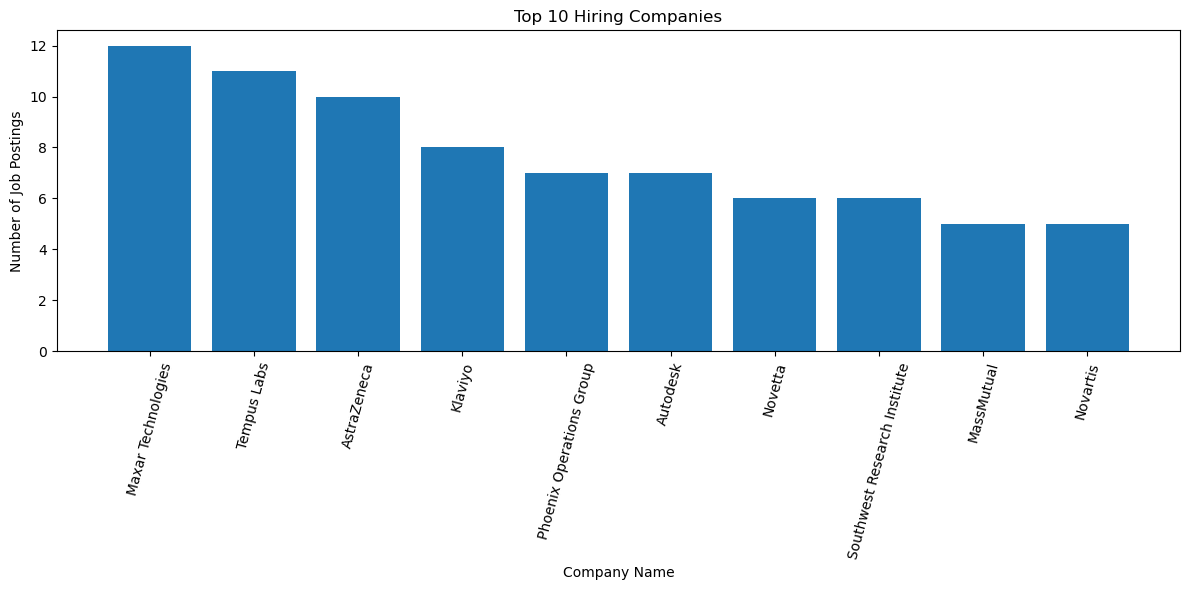

In [19]:
plt.figure(figsize=(12,6))
plt.bar(top_companies.index, top_companies.values)
plt.xticks(rotation=75)
plt.title("Top 10 Hiring Companies")
plt.xlabel("Company Name")
plt.ylabel("Number of Job Postings")
plt.tight_layout()
plt.show()

## 8. Skill Demand Analysis

In [20]:
skill_columns = ['python', 'excel', 'hadoop', 'spark']
print(df[skill_columns].head())

   python  excel  hadoop  spark
0       0      0       0      0
1       0      0       1      0
2       1      1       0      0
3       1      1       0      0
4       1      1       0      0


In [21]:
skill_counts = df[skill_columns].sum().sort_values(ascending=False)
print(skill_counts)

python    470
excel     290
spark     174
hadoop    139
dtype: int64


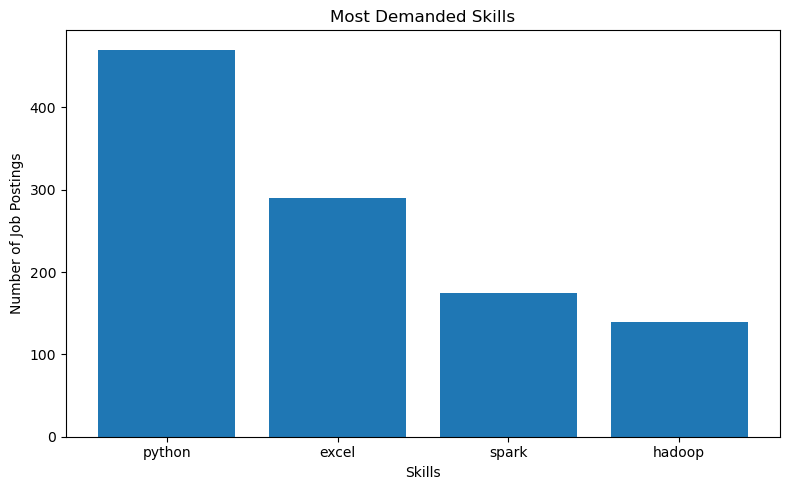

In [22]:
plt.figure(figsize=(8,5))
plt.bar(skill_counts.index, skill_counts.values)
plt.title("Most Demanded Skills")
plt.xlabel("Skills")
plt.ylabel("Number of Job Postings")
plt.tight_layout()
plt.show()

In [23]:
for skill in skill_columns:
    avg_rating = df[df[skill] == 1]['Rating'].mean()
    print(f"Average rating for jobs requiring {skill}: {avg_rating:.2f}")

Average rating for jobs requiring python: 3.73
Average rating for jobs requiring excel: 3.56
Average rating for jobs requiring hadoop: 3.72
Average rating for jobs requiring spark: 3.75


## 9. Observations
- Python is one of the most in-demand skills in Data Science job postings.
- Excel is also required in many job roles, showing its continued importance.
- Some industries and sectors are hiring more Data Science professionals than others.
- A few job titles appear much more frequently, indicating common roles in the market.
- Hadoop and Spark appear in fewer jobs compared to Python, but they are important for big data-related roles.

## 10. Conclusion

- This project analyzed data science job postings to understand job trends.
- Python is the most in-demand skill in the job market.
- Excel is also widely used across many job roles.
- Spark and Hadoop are less frequent but important for big data roles.
- The analysis helps identify important skills for a career in data science.